LOGISTIC REGRESSION - MULTI CLASS REGRESSION (MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving digital_mirror_research_dataset_870_rows.csv to digital_mirror_research_dataset_870_rows.csv


In [ ]:
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded['digital_mirror_research_dataset_870_rows.csv']))

df.head()

,participant_id,age,gender,occupation,daily_usage_hours,night_usage_hours,app_switch_frequency,notification_check_frequency,short_video_consumption_rate,average_session_duration,...,rage_content_exposure,emotional_trigger_sensitivity,behavioral_text,sentiment_score,toxicity_score,emotional_tone,addiction_risk_level,behavioral_risk_score,algorithmic_influence_score,digital_behavioral_risk_index
0,P0001,32,Other,Creator,2.4,1.1,15,102,6.1,29.4,...,7.1,3.9,I rarely spend too much time online.,0.79,0.53,Calm,Low,23.0,3.1,27.0
1,P0002,27,Other,Employee,3.9,3.8,20,58,8.9,22.9,...,9.6,3.8,I can control my screen usage effectively.,-0.18,0.72,Calm,Low,21.2,4.0,31.4
2,P0003,33,Female,Freelancer,3.7,0.2,31,68,6.5,71.2,...,6.1,8.6,I rarely spend too much time online.,-0.27,0.17,Calm,Low,20.6,3.5,35.6
3,P0004,32,Male,College Student,10.1,0.1,16,109,8.1,28.3,...,1.4,2.5,I spend hours watching shorts without realizin...,0.76,0.40,Stressed,High,92.8,9.2,77.7
4,P0005,25,Other,Creator,1.8,1.0,15,141,3.1,83.7,...,6.5,1.6,I mainly use YouTube for learning.,0.66,0.36,Neutral,Low,14.0,1.8,33.9


In [ ]:
print(df.shape)

print(df.columns)

df.info()

(870, 40)
Index(['participant_id', 'age', 'gender', 'occupation', 'daily_usage_hours',
       'night_usage_hours', 'app_switch_frequency',
       'notification_check_frequency', 'short_video_consumption_rate',
       'average_session_duration', 'dopamine_trigger_score',
       'emotional_dependency_score', 'social_validation_dependency',
       'impulsive_usage_score', 'emotional_instability_score',
       'cognitive_fatigue_score', 'loneliness_indicator_score',
       'anxiety_level', 'attention_fragmentation_index', 'concentration_score',
       'multitasking_dependency', 'content_switching_rate',
       'attention_span_estimate', 'sleep_hours', 'sleep_disruption_score',
       'fatigue_after_usage', 'morning_tiredness_score',
       'preferred_content_type', 'negativity_exposure_score',
       'overstimulation_index', 'rage_content_exposure',
       'emotional_trigger_sensitivity', 'behavioral_text', 'sentiment_score',
       'toxicity_score', 'emotional_tone', 'addiction_risk_level

In [ ]:
print(df.isnull().sum())

participant_id                   0
age                              0
gender                           0
occupation                       0
daily_usage_hours                0
night_usage_hours                0
app_switch_frequency             0
notification_check_frequency     0
short_video_consumption_rate     0
average_session_duration         0
dopamine_trigger_score           0
emotional_dependency_score       0
social_validation_dependency     0
impulsive_usage_score            0
emotional_instability_score      0
cognitive_fatigue_score          0
loneliness_indicator_score       0
anxiety_level                    0
attention_fragmentation_index    0
concentration_score              0
multitasking_dependency          0
content_switching_rate           0
attention_span_estimate          0
sleep_hours                      0
sleep_disruption_score           0
fatigue_after_usage              0
morning_tiredness_score          0
preferred_content_type           0
negativity_exposure_

In [ ]:
df = df.drop(['participant_id', 'behavioral_text'], axis=1)

In [ ]:
X = df.drop('addiction_risk_level', axis=1)

y = df['addiction_risk_level']

In [ ]:
X = pd.get_dummies(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

['Moderate' 'Moderate' 'High' 'High' 'High' 'Low' 'Moderate' 'High' 'High'
 'Moderate' 'Low' 'Low' 'High' 'High' 'Moderate' 'High' 'Low' 'Moderate'
 'High' 'High' 'Low' 'Low' 'Low' 'Moderate' 'High' 'High' 'Moderate'
 'Moderate' 'High' 'Moderate' 'Moderate' 'Moderate' 'High' 'Moderate'
 'High' 'Low' 'Low' 'Moderate' 'High' 'Low' 'High' 'Low' 'Moderate' 'Low'
 'Low' 'Low' 'Low' 'Low' 'Moderate' 'Moderate' 'High' 'Low' 'Moderate'
 'Low' 'Low' 'High' 'Moderate' 'High' 'Moderate' 'Low' 'High' 'Low'
 'Moderate' 'Low' 'Moderate' 'High' 'Moderate' 'High' 'Moderate'
 'Moderate' 'Moderate' 'Moderate' 'Low' 'High' 'High' 'Moderate' 'Low'
 'Low' 'Moderate' 'Low' 'Low' 'High' 'High' 'Low' 'High' 'High' 'High'
 'Low' 'Low' 'Moderate' 'Moderate' 'High' 'Low' 'Moderate' 'High' 'High'
 'High' 'High' 'Low' 'High' 'High' 'Moderate' 'Moderate' 'Moderate' 'High'
 'Low' 'Low' 'High' 'Moderate' 'High' 'Moderate' 'Low' 'Moderate' 'Low'
 'Moderate' 'Moderate' 'Low' 'High' 'Low' 'Low' 'High' 'High' 'Low'
 'Mod

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


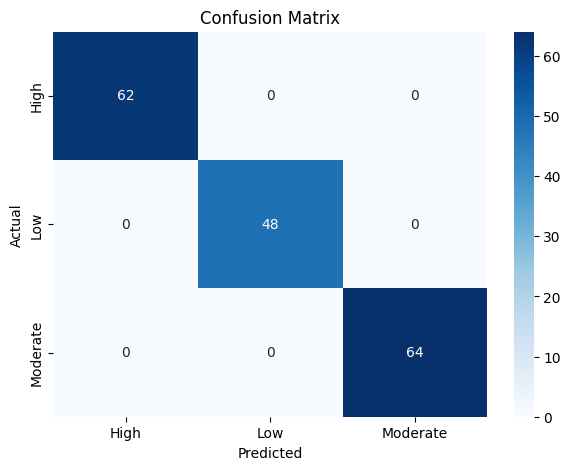

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        62
         Low       1.00      1.00      1.00        48
    Moderate       1.00      1.00      1.00        64

    accuracy                           1.00       174
   macro avg       1.00      1.00      1.00       174
weighted avg       1.00      1.00      1.00       174



In [ ]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Addiction Risk Level:", prediction[0])

Predicted Addiction Risk Level: Low


DECISION TREE CLASSIFICATION (MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumption_rate  average_session_duration  ...  \
0                           6.1                      29.4  ...

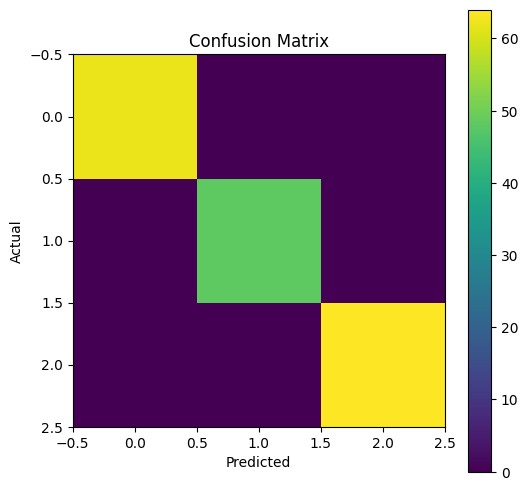


Insight 1
Prediction : [1]

Insight 2
Prediction : [2]

Insight 3
Prediction : [0]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())

print(df.info())

print(df.describe())

target_column = "addiction_risk_level"

print(df.groupby(target_column).mean(numeric_only=True))

categorical_columns = df.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

X = df.drop(target_column, axis=1)

y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix :")

print(cm)

print("\nClassification Report :")

print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

print("\nInsight 1")

sample1 = X.iloc[0:1]

prediction1 = model.predict(sample1)

print("Prediction :", prediction1)

print("\nInsight 2")

sample2 = X.iloc[10:11]

prediction2 = model.predict(sample2)

print("Prediction :", prediction2)

print("\nInsight 3")

sample3 = X.iloc[20:21]

prediction3 = model.predict(sample3)

print("Prediction :", prediction3)

### Visualize Decision Tree

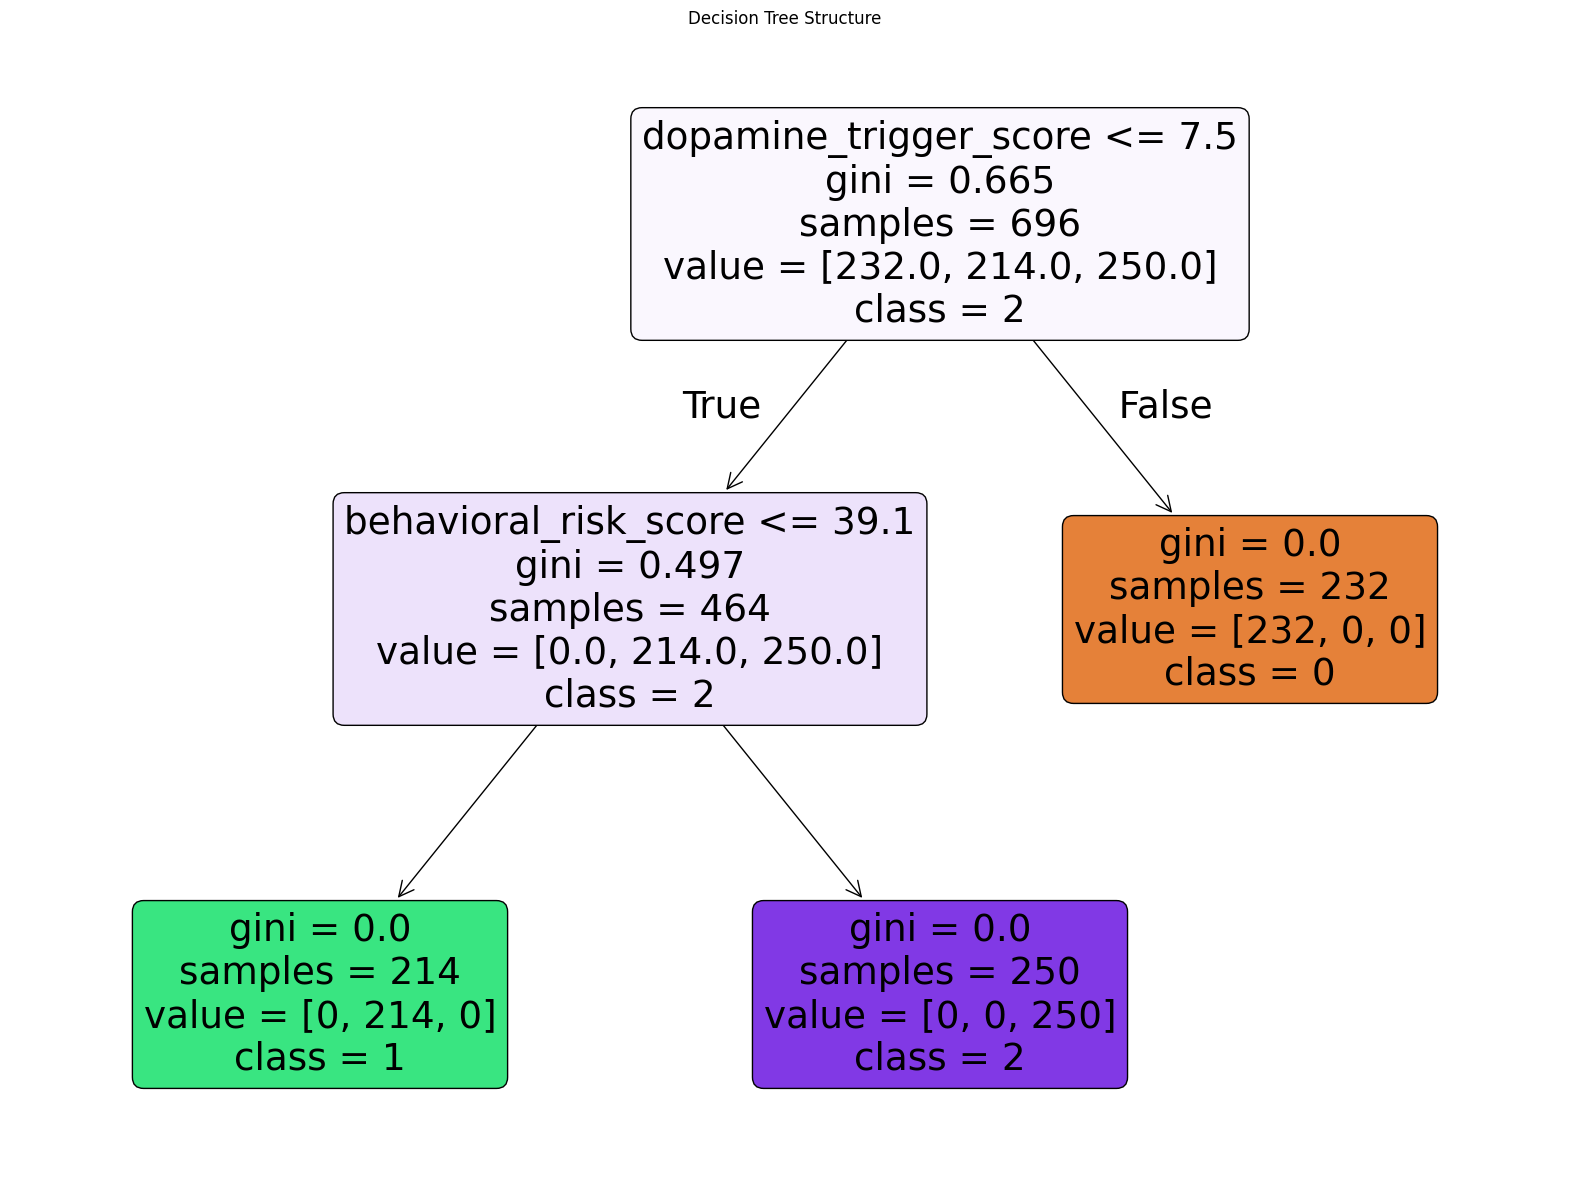

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
plot_tree(model, filled=True, feature_names=X.columns.tolist(), class_names=[str(c) for c in model.classes_], rounded=True)
plt.title("Decision Tree Structure")
plt.show()

SUPPORT VECTOR MACHINE (MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumption_rate  average_session_duration  ...  \
0                           6.1                      29.4  ...

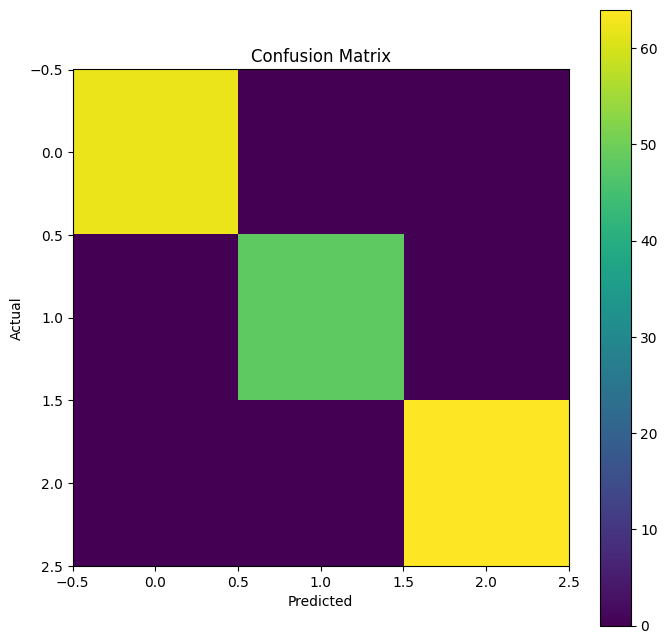


Insight 1
[2]

Insight 2
[2]

Insight 3
[0]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())

print(df.info())

print(df.describe())

target_column = "addiction_risk_level"

categorical_columns = df.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

X = df.drop(target_column, axis=1)

y = df[target_column]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    train_size=0.8,
    random_state=42
)

linear_model = SVC(kernel='linear')

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_accuracy = accuracy_score(y_test, linear_pred)

print("\nLinear Kernel Accuracy :")

print(linear_accuracy)

rbf_model = SVC(kernel='rbf')

rbf_model.fit(X_train, y_train)

rbf_pred = rbf_model.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)

print("\nRBF Kernel Accuracy :")

print(rbf_accuracy)

tuned_model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01
)

tuned_model.fit(X_train, y_train)

tuned_pred = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)

print("\nTuned Model Accuracy :")

print(tuned_accuracy)

cm = confusion_matrix(y_test, tuned_pred)

print("\nConfusion Matrix :")

print(cm)

print("\nClassification Report :")

print(classification_report(y_test, tuned_pred))

plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

print("\nInsight 1")

sample1 = X_test[0].reshape(1, -1)

print(tuned_model.predict(sample1))

print("\nInsight 2")

sample2 = X_test[1].reshape(1, -1)

print(tuned_model.predict(sample2))

print("\nInsight 3")

sample3 = X_test[2].reshape(1, -1)

print(tuned_model.predict(sample3))

RANDOM FOREST (MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumption_rate  average_session_duration  ...  \
0                           6.1                      29.4  ...

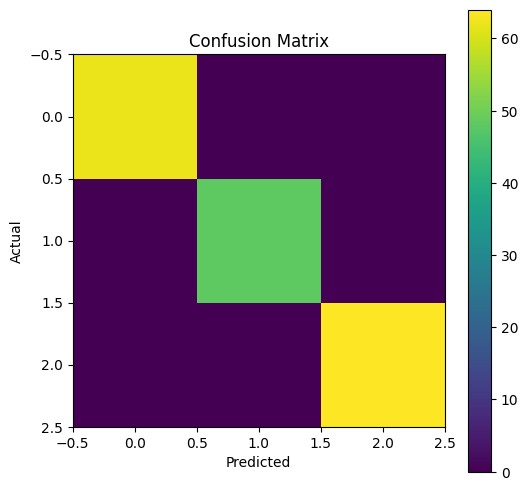

Accuracy with 5 trees : 1.0
Accuracy with 10 trees : 1.0
Accuracy with 20 trees : 1.0
Accuracy with 30 trees : 1.0
Accuracy with 50 trees : 1.0
Accuracy with 70 trees : 1.0
Accuracy with 100 trees : 1.0

Best Accuracy Score :
1.0

Best Number of Trees :
5


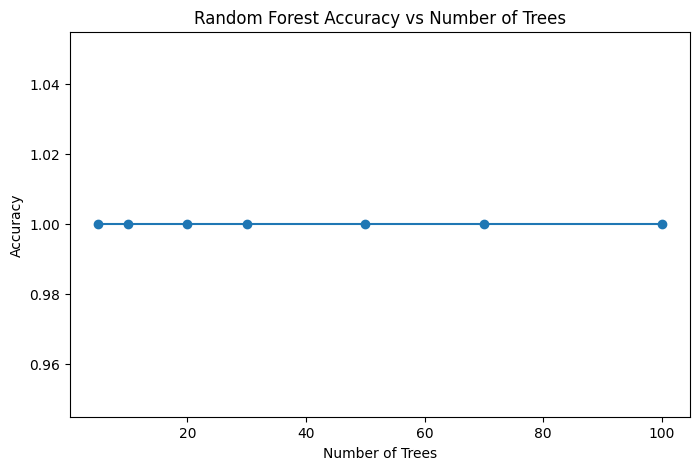


Insight 1
[2]

Insight 2
[2]

Insight 3
[0]


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('digital_mirror_research_dataset_870_rows.csv')

print(df.head())

print(df.info())

print(df.describe())

target_column = "addiction_risk_level"

categorical_columns = df.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

X = df.drop(target_column, axis=1)

y = df[target_column]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

default_accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy with Default n_estimators=10 :")

print(default_accuracy)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix :")

print(cm)

print("\nClassification Report :")

print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

scores = []

tree_values = [5, 10, 20, 30, 50, 70, 100]

for n in tree_values:

    tuned_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    tuned_model.fit(X_train, y_train)

    tuned_pred = tuned_model.predict(X_test)

    score = accuracy_score(y_test, tuned_pred)

    scores.append(score)

    print(f"Accuracy with {n} trees :", score)

best_score = max(scores)

best_trees = tree_values[scores.index(best_score)]

print("\nBest Accuracy Score :")

print(best_score)

print("\nBest Number of Trees :")

print(best_trees)

plt.figure(figsize=(8,5))

plt.plot(tree_values, scores, marker='o')

plt.xlabel("Number of Trees")

plt.ylabel("Accuracy")

plt.title("Random Forest Accuracy vs Number of Trees")

plt.show()

print("\nInsight 1")

sample1 = X_test[0].reshape(1, -1)

print(tuned_model.predict(sample1))

print("\nInsight 2")

sample2 = X_test[1].reshape(1, -1)

print(tuned_model.predict(sample2))

print("\nInsight 3")

sample3 = X_test[2].reshape(1, -1)

print(tuned_model.predict(sample3))

K-MEANS CLUSTERING (MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumption_rate  average_session_duration  ...  \
0                           6.1                      29.4  ...

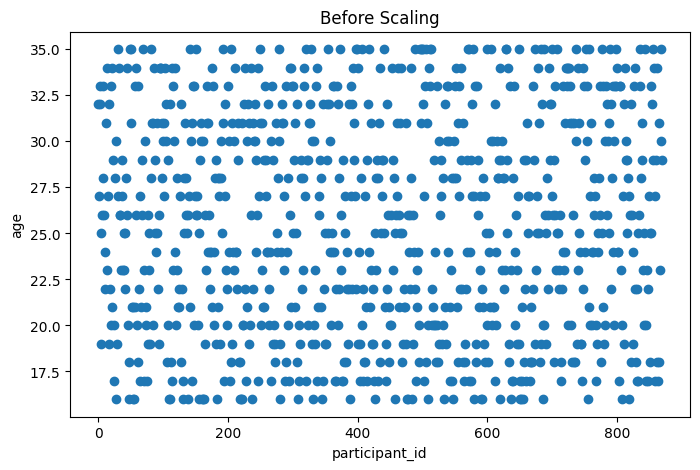


After Min Max Scaling

   participant_id       age
0        0.000000  0.842105
1        0.001151  0.578947
2        0.002301  0.894737
3        0.003452  0.842105
4        0.004603  0.473684


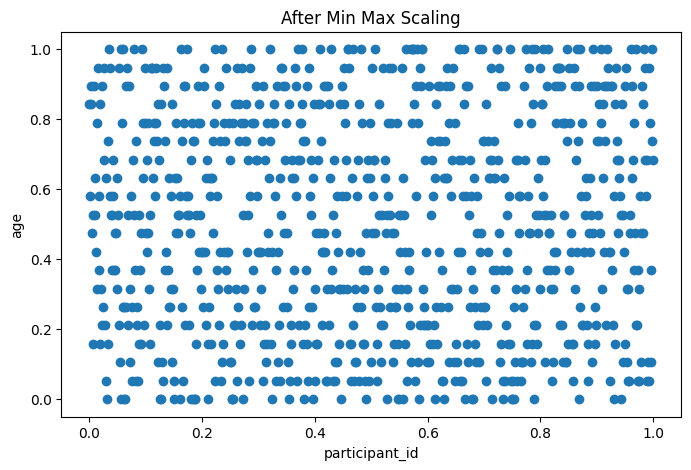

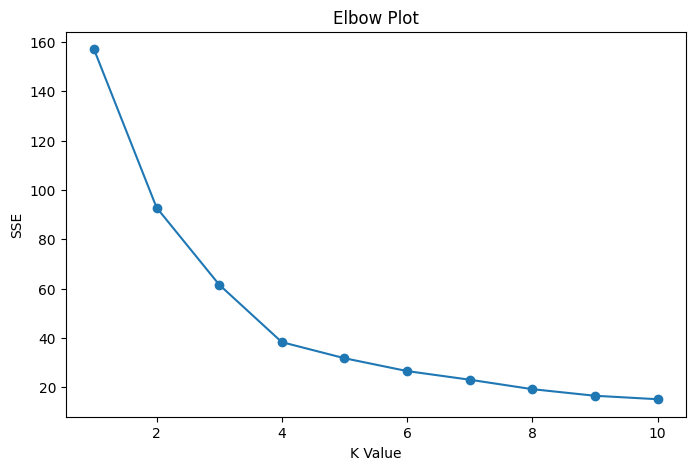


Clustered Data

   participant_id       age  Cluster
0        0.000000  0.842105        0
1        0.001151  0.578947        2
2        0.002301  0.894737        0
3        0.003452  0.842105        0
4        0.004603  0.473684        2


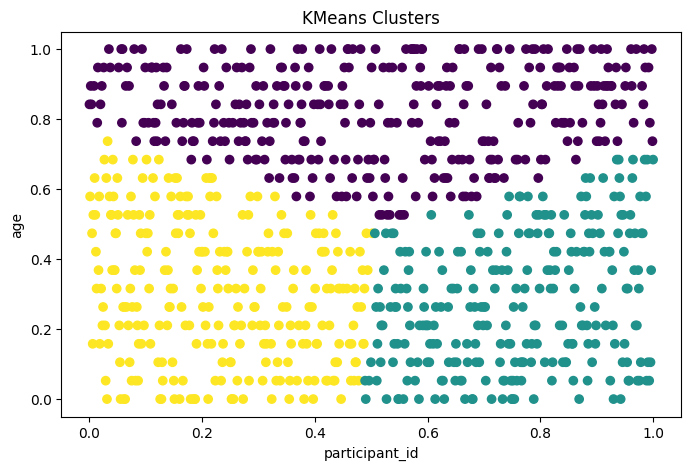


Optimal K Value :
3


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())

print(df.info())

print(df.describe())

categorical_columns = df.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

features = df.iloc[:, 0:2]

print("\nSelected Features\n")

print(features.head())

plt.figure(figsize=(8,5))

plt.scatter(
    features.iloc[:,0],
    features.iloc[:,1]
)

plt.xlabel(features.columns[0])

plt.ylabel(features.columns[1])

plt.title("Before Scaling")

plt.show()

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features.columns
)

print("\nAfter Min Max Scaling\n")

print(scaled_df.head())

plt.figure(figsize=(8,5))

plt.scatter(
    scaled_df.iloc[:,0],
    scaled_df.iloc[:,1]
)

plt.xlabel(features.columns[0])

plt.ylabel(features.columns[1])

plt.title("After Min Max Scaling")

plt.show()

sse = []

k_values = range(1, 11)

for k in k_values:

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(scaled_df)

    sse.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    sse,
    marker='o'
)

plt.xlabel("K Value")

plt.ylabel("SSE")

plt.title("Elbow Plot")

plt.show()

optimal_k = 3

model = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

y_pred = model.fit_predict(scaled_df)

scaled_df['Cluster'] = y_pred

print("\nClustered Data\n")

print(scaled_df.head())

plt.figure(figsize=(8,5))

plt.scatter(
    scaled_df.iloc[:,0],
    scaled_df.iloc[:,1],
    c=scaled_df['Cluster']
)

plt.xlabel(features.columns[0])

plt.ylabel(features.columns[1])

plt.title("KMeans Clusters")

plt.show()

print("\nOptimal K Value :")

print(optimal_k)